<a href="https://colab.research.google.com/github/ShawneilRodrigues/AI-cookbook/blob/main/Qwen3_5_4B_Sarvam105B_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installation

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

### Unsloth

In [2]:
from unsloth import FastLanguageModel
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Qwen3-4B-bnb-4bit",
    "unsloth/Qwen3-8B-bnb-4bit",
    "unsloth/Qwen3-14B-bnb-4bit",
    "unsloth/Qwen3-32B-bnb-4bit",
    "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    "unsloth/Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/gemma-2-9b-it-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    "unsloth/Qwen3-4B",
    max_seq_length = 2048,
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    dtype = None, # None for auto detection
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.3: Fast Qwen3 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-4B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 64,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2026.3.3 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


<a name="Data"></a>
### Data Prep
We'll be using the **neuralnets/distilled-data-sarvam-105b** dataset which contains math questions and answers with different problem types. This dataset has ~31.9k rows with columns: Index, Type, Question, Answer.

You can access the dataset [here](https://huggingface.co/datasets/neuralnets/distilled-data-sarvam-105b).

In [4]:
from datasets import load_dataset
dataset = load_dataset("neuralnets/distilled-data-sarvam-105b", split="train")

README.md:   0%|          | 0.00/383 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/31870 [00:00<?, ? examples/s]

Let's take an overview look at the dataset structure and explore the data.

In [5]:
# Display dataset info
print(f"Dataset size: {len(dataset)}")
print(f"\nColumns: {dataset.column_names}")
print(f"\nFeatures: {dataset.features}")
dataset

Dataset size: 31870

Columns: ['Index', 'Type', 'Question', 'Answer']

Features: {'Index': Value('int64'), 'Type': Value('string'), 'Question': Value('string'), 'Answer': Value('string')}


Dataset({
    features: ['Index', 'Type', 'Question', 'Answer'],
    num_rows: 31870
})

In [6]:
# Install visualization libraries and convert to pandas
!pip install -q matplotlib seaborn plotly wordcloud kaleido

import pandas as pd
import plotly.io as pio

# Configure Plotly to include static images for GitHub rendering
pio.renderers.default = 'notebook_connected+png'

df = dataset.to_pandas()
df.head(10)

In [7]:
# Basic statistics
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nUnique Types:", df['Type'].nunique())
print("Types:", df['Type'].unique())

Dataset Shape: (31870, 4)

Data Types:
Index        int64
Type        object
Question    object
Answer      object
dtype: object

Missing Values:
Index       0
Type        0
Question    0
Answer      0
dtype: int64

Unique Types: 4
Types: ['math' 'code' 'instruction' 'multilingual']


## Comprehensive Data Visualization
Let's explore the dataset with various visualizations to understand its structure and characteristics.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from collections import Counter

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

To format the dataset for text-based fine-tuning, we structure it as conversations:

```python
[
{ "role": "user",
  "content": question
},
{ "role": "assistant",
  "content": answer
},
]
```

In [9]:
def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content": sample["Question"]
        },
        { "role": "assistant",
          "content": sample["Answer"]
        },
    ]
    return { "messages" : conversation }

# Convert dataset
converted_dataset = [convert_to_conversation(sample) for sample in dataset]
print(f"Converted {len(converted_dataset)} samples")

Converted 31870 samples


### 1. Distribution of Question Types (Bar Chart & Pie Chart)

# Bar chart & Pie chart - Type distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get type counts
type_counts = df['Type'].value_counts()
colors = plt.cm.viridis(np.linspace(0, 1, len(type_counts)))

# 1. Matplotlib bar chart
axes[0, 0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_xlabel('Question Type', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].set_title('Distribution of Question Types (Bar Chart)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(type_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Seaborn countplot
sns.countplot(data=df, x='Type', ax=axes[0, 1], palette='viridis', order=type_counts.index)
axes[0, 1].set_xlabel('Question Type', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('Distribution of Question Types (Seaborn)', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Pie chart
pie_colors = plt.cm.Set3(np.linspace(0, 1, len(type_counts)))
wedges, texts, autotexts = axes[1, 0].pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    colors=pie_colors, explode=[0.05]*len(type_counts), shadow=True, startangle=90
)
axes[1, 0].set_title('Question Type Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# 4. Donut chart
wedges2, texts2, autotexts2 = axes[1, 1].pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=90, pctdistance=0.75
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1, 1].add_patch(centre_circle)
axes[1, 1].set_title('Question Type Distribution (Donut Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Get type counts
type_counts = df['Type'].value_counts()

# Interactive Plotly Charts
# Bar chart
fig = px.bar(
    x=type_counts.index, y=type_counts.values, color=type_counts.index,
    title='Interactive Distribution of Question Types',
    labels={'x': 'Question Type', 'y': 'Count'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(xaxis_title='Question Type', yaxis_title='Count', showlegend=False, template='plotly_white')
fig.show()

# Pie chart
fig = px.pie(
    values=type_counts.values, names=type_counts.index,
    title='Interactive Question Type Distribution',
    color_discrete_sequence=px.colors.qualitative.Pastel, hole=0.3
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

### 2. Question and Answer Length Analysis

Question Length Statistics:
count    31870.00000
mean       160.61321
std        307.95234
min          2.00000
25%         41.00000
50%         63.00000
75%        131.00000
max       4352.00000
Name: question_length, dtype: float64

Answer Length Statistics:
count    31870.000000
mean       756.556072
std        774.608593
min          0.000000
25%        236.000000
50%        521.000000
75%       1067.000000
max      10212.000000
Name: answer_length, dtype: float64


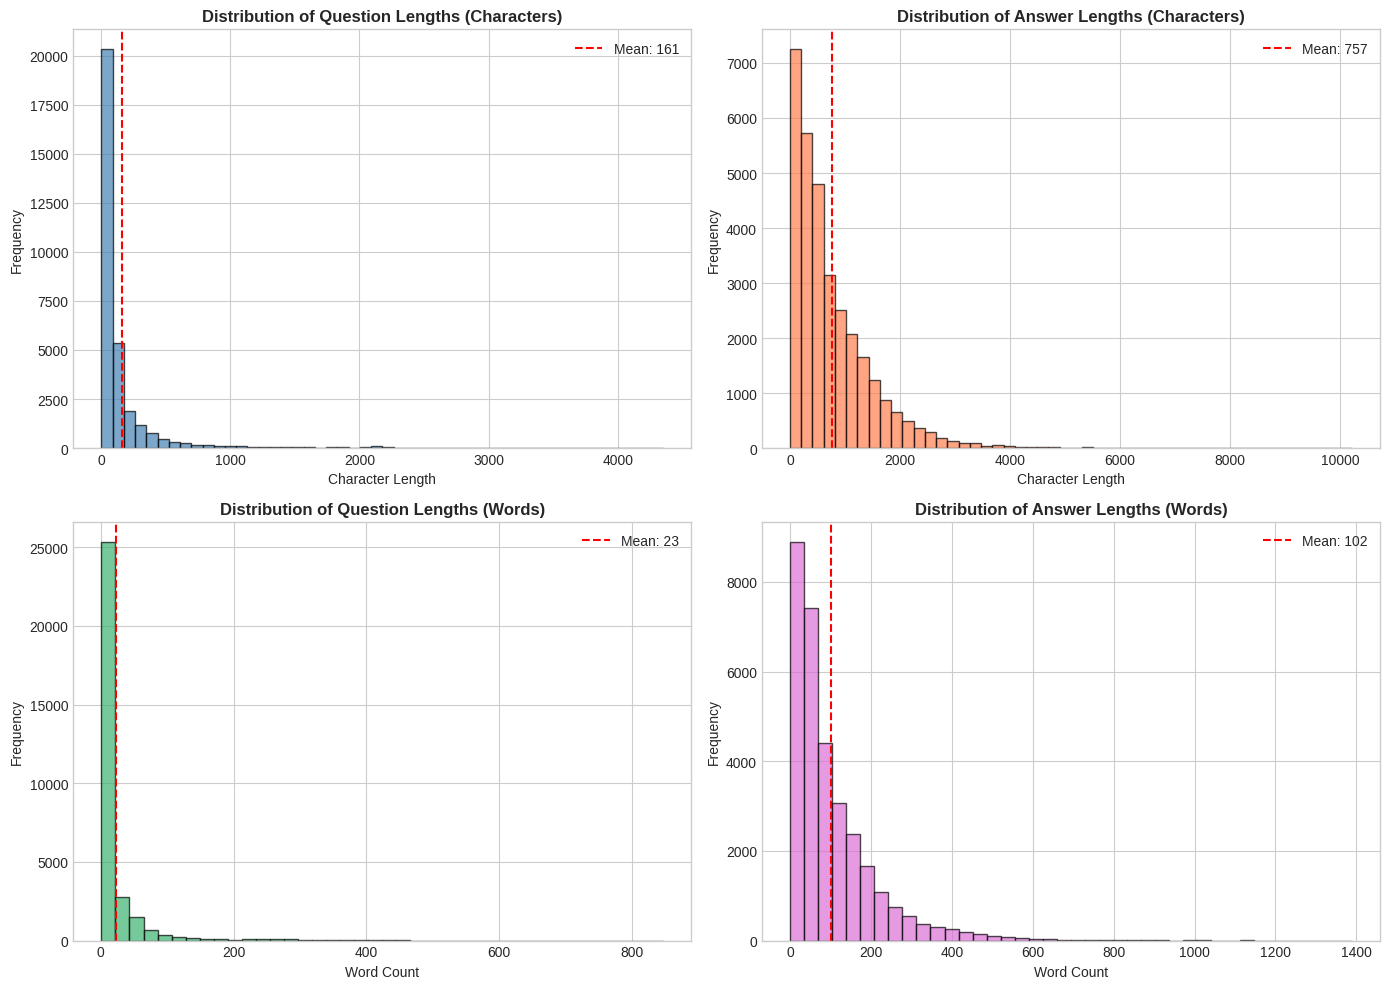

In [11]:
# Add text length columns for analysis
df['question_length'] = df['Question'].str.len()
df['answer_length'] = df['Answer'].str.len()
df['question_word_count'] = df['Question'].str.split().str.len()
df['answer_word_count'] = df['Answer'].str.split().str.len()

print("Question Length Statistics:")
print(df['question_length'].describe())
print("\nAnswer Length Statistics:")
print(df['answer_length'].describe())

# Histogram - Question and Answer lengths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['question_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Question Lengths (Characters)', fontweight='bold')
axes[0, 0].axvline(df['question_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["question_length"].mean():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(df['answer_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Character Length')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Answer Lengths (Characters)', fontweight='bold')
axes[0, 1].axvline(df['answer_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["answer_length"].mean():.0f}')
axes[0, 1].legend()

axes[1, 0].hist(df['question_word_count'], bins=40, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Question Lengths (Words)', fontweight='bold')
axes[1, 0].axvline(df['question_word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["question_word_count"].mean():.0f}')
axes[1, 0].legend()

axes[1, 1].hist(df['answer_word_count'], bins=40, color='orchid', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Answer Lengths (Words)', fontweight='bold')
axes[1, 1].axvline(df['answer_word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["answer_word_count"].mean():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 3. Box Plots, Violin Plots & Scatter Plots

/tmp/ipykernel_947/279153738.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_947/279153738.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_947/279153738.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_947/279153738.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




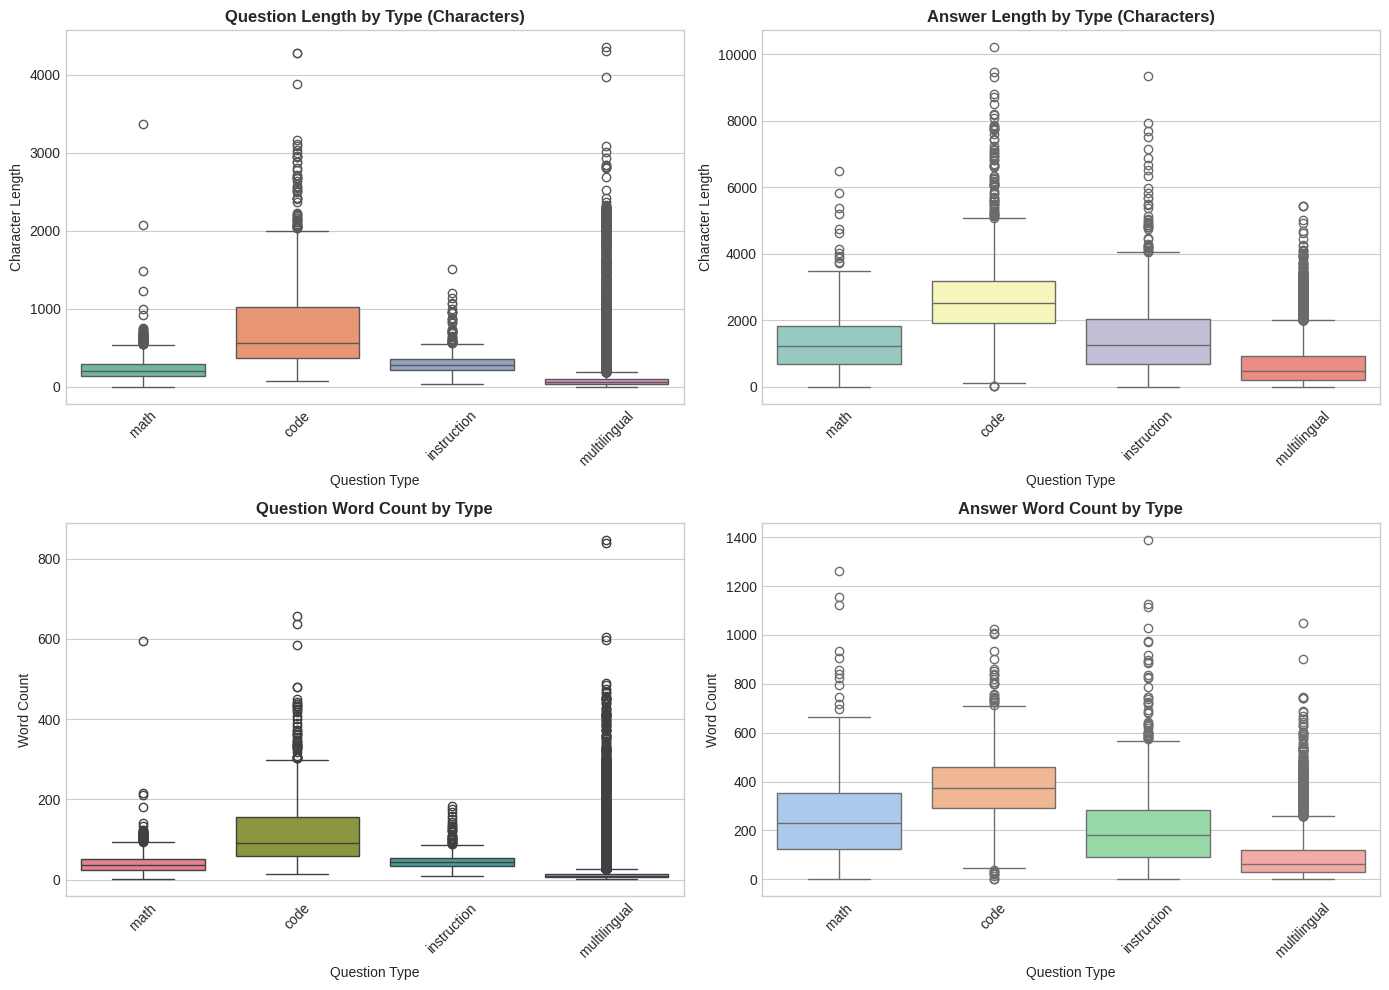

In [12]:
# Box plots by type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Type', y='question_length', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_xlabel('Question Type')
axes[0, 0].set_ylabel('Character Length')
axes[0, 0].set_title('Question Length by Type (Characters)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Type', y='answer_length', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_xlabel('Question Type')
axes[0, 1].set_ylabel('Character Length')
axes[0, 1].set_title('Answer Length by Type (Characters)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Type', y='question_word_count', ax=axes[1, 0], palette='husl')
axes[1, 0].set_xlabel('Question Type')
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Question Word Count by Type', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Type', y='answer_word_count', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_xlabel('Question Type')
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_title('Answer Word Count by Type', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_947/3099555913.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_947/3099555913.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




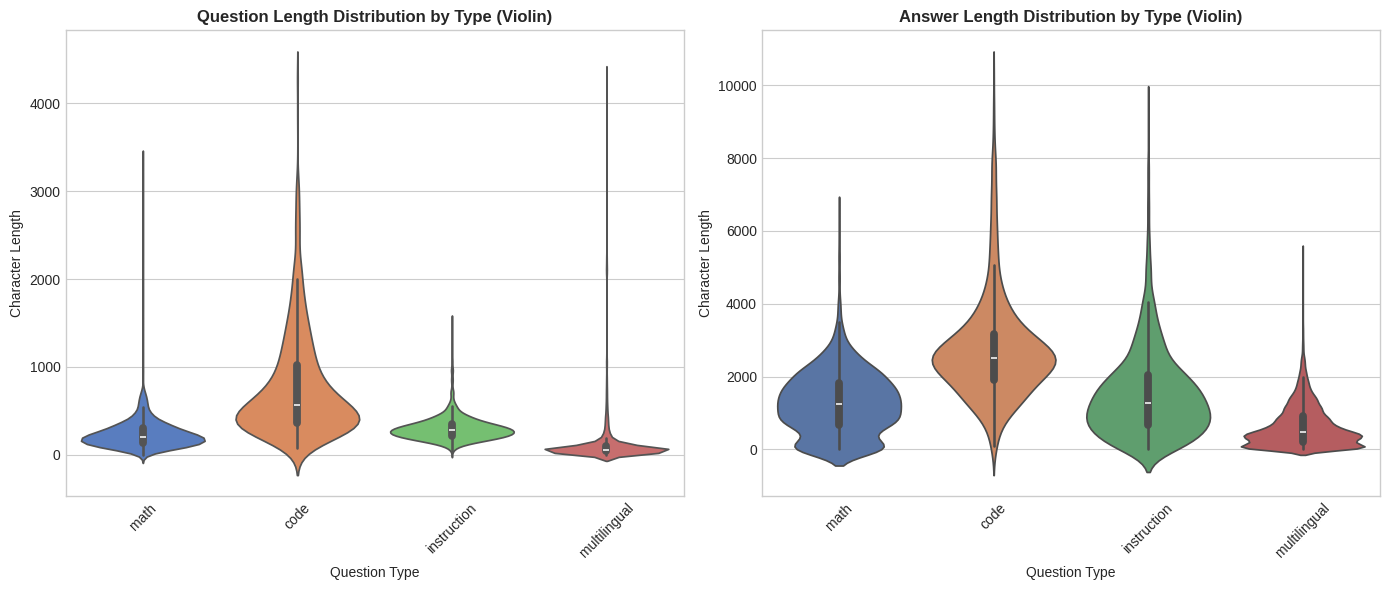

In [13]:
# Violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='Type', y='question_length', ax=axes[0], palette='muted')
axes[0].set_xlabel('Question Type')
axes[0].set_ylabel('Character Length')
axes[0].set_title('Question Length Distribution by Type (Violin)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=df, x='Type', y='answer_length', ax=axes[1], palette='deep')
axes[1].set_xlabel('Question Type')
axes[1].set_ylabel('Character Length')
axes[1].set_title('Answer Length Distribution by Type (Violin)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

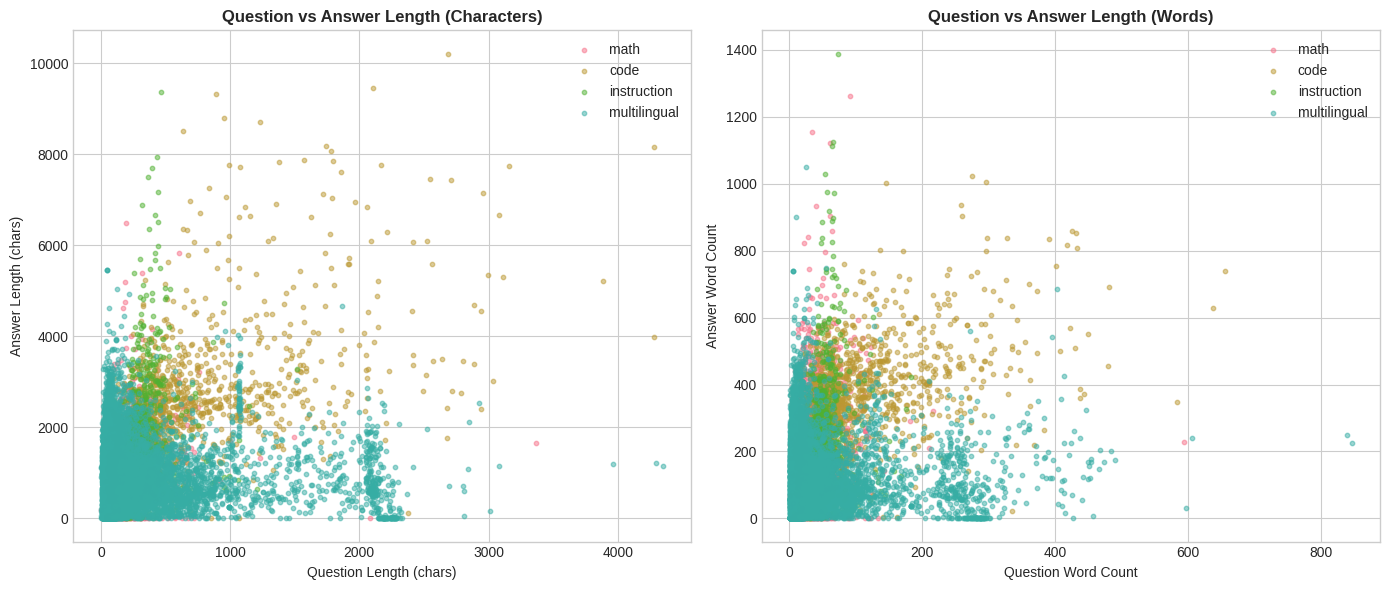

In [14]:
# Scatter plot - Question vs Answer length
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    axes[0].scatter(subset['question_length'], subset['answer_length'], alpha=0.5, label=qtype, s=10)
axes[0].set_xlabel('Question Length (chars)')
axes[0].set_ylabel('Answer Length (chars)')
axes[0].set_title('Question vs Answer Length (Characters)', fontweight='bold')
axes[0].legend()

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    axes[1].scatter(subset['question_word_count'], subset['answer_word_count'], alpha=0.5, label=qtype, s=10)
axes[1].set_xlabel('Question Word Count')
axes[1].set_ylabel('Answer Word Count')
axes[1].set_title('Question vs Answer Length (Words)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Interactive scatter with Plotly
fig = px.scatter(
    df, x='question_length', y='answer_length', color='Type',
    title='Interactive: Question vs Answer Length by Type',
    labels={'question_length': 'Question Length (chars)', 'answer_length': 'Answer Length (chars)'},
    opacity=0.6, color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_layout(template='plotly_white')
fig.show()

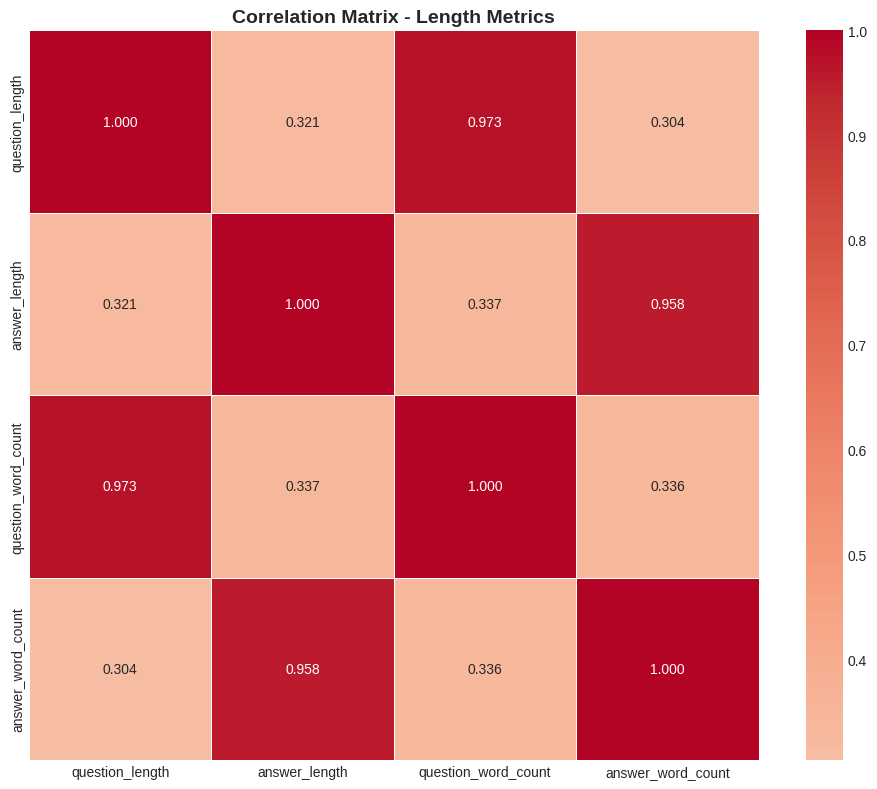

In [15]:
# Correlation heatmap
numeric_cols = ['question_length', 'answer_length', 'question_word_count', 'answer_word_count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix - Length Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. KDE Plots, CDFs & Grouped Statistics

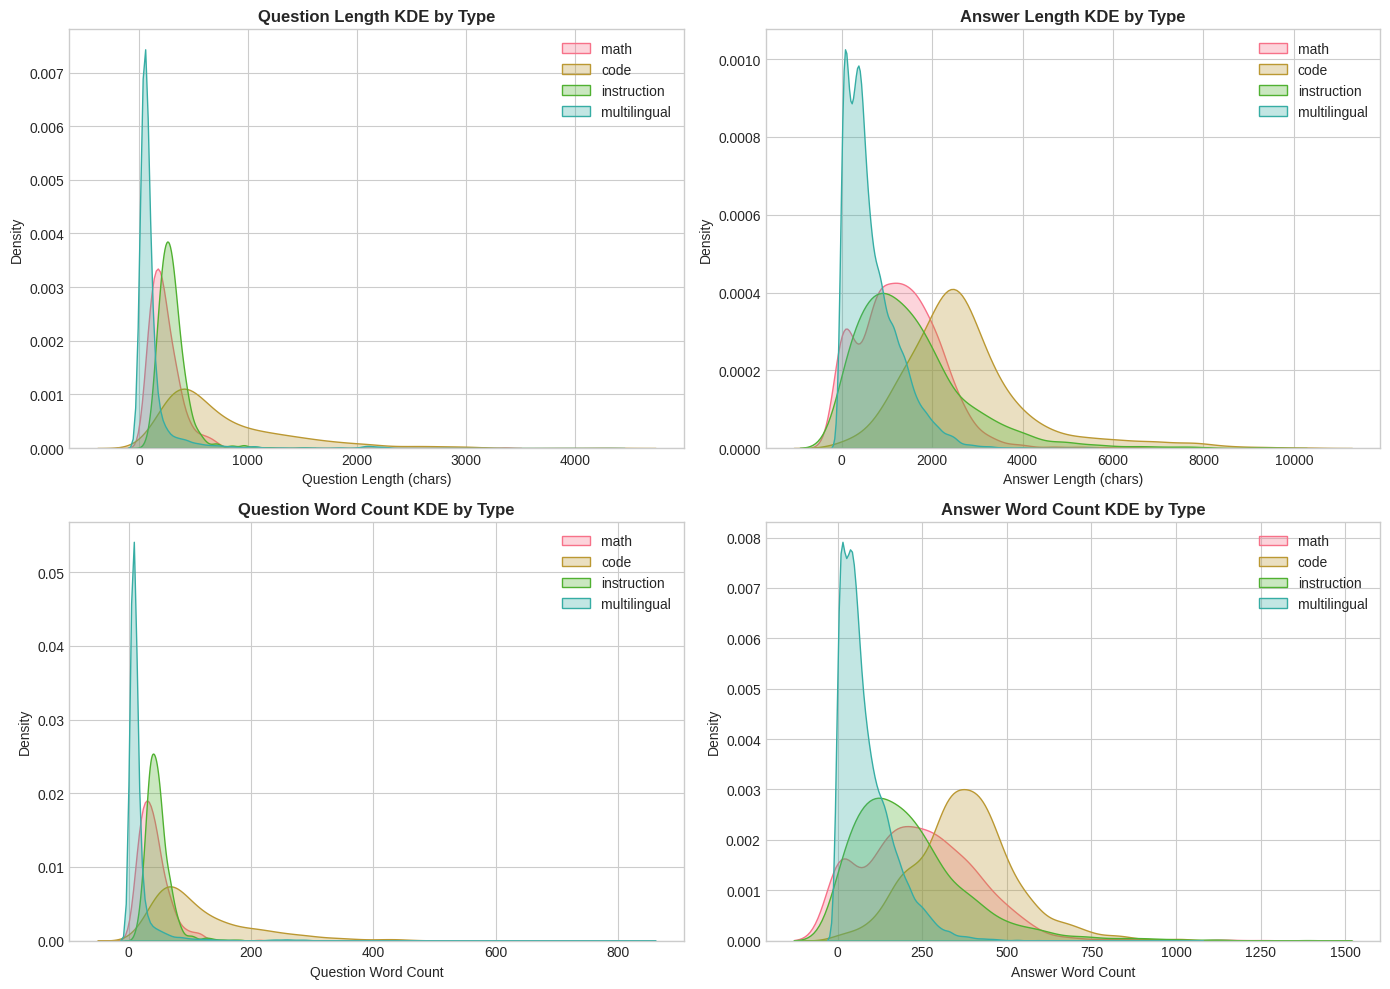

In [16]:
# KDE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    sns.kdeplot(subset['question_length'], ax=axes[0, 0], label=qtype, fill=True, alpha=0.3)
axes[0, 0].set_xlabel('Question Length (chars)')
axes[0, 0].set_title('Question Length KDE by Type', fontweight='bold')
axes[0, 0].legend()

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    sns.kdeplot(subset['answer_length'], ax=axes[0, 1], label=qtype, fill=True, alpha=0.3)
axes[0, 1].set_xlabel('Answer Length (chars)')
axes[0, 1].set_title('Answer Length KDE by Type', fontweight='bold')
axes[0, 1].legend()

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    sns.kdeplot(subset['question_word_count'], ax=axes[1, 0], label=qtype, fill=True, alpha=0.3)
axes[1, 0].set_xlabel('Question Word Count')
axes[1, 0].set_title('Question Word Count KDE by Type', fontweight='bold')
axes[1, 0].legend()

for qtype in df['Type'].unique():
    subset = df[df['Type'] == qtype]
    sns.kdeplot(subset['answer_word_count'], ax=axes[1, 1], label=qtype, fill=True, alpha=0.3)
axes[1, 1].set_xlabel('Answer Word Count')
axes[1, 1].set_title('Answer Word Count KDE by Type', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 5. Word Clouds & Interactive Charts

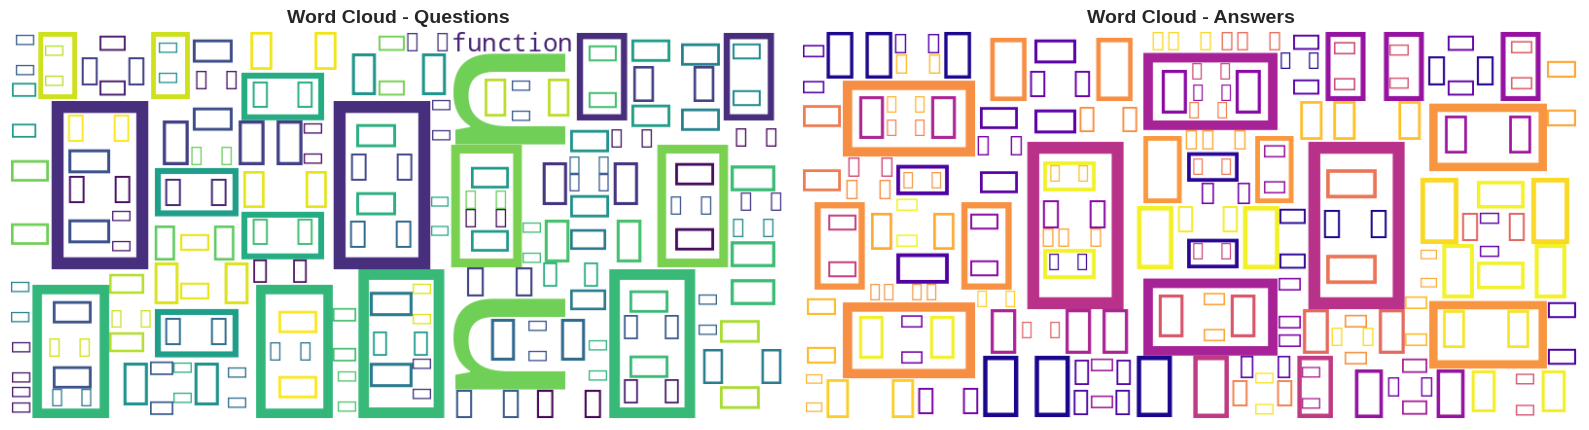

In [17]:
from wordcloud import WordCloud

# Word clouds
all_questions = ' '.join(df['Question'].astype(str).tolist())
all_answers = ' '.join(df['Answer'].astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wordcloud_q = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(all_questions)
axes[0].imshow(wordcloud_q, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Questions', fontsize=14, fontweight='bold')

wordcloud_a = WordCloud(width=800, height=400, background_color='white', colormap='plasma', max_words=100).generate(all_answers)
axes[1].imshow(wordcloud_a, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Answers', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Word clouds by type
types = df['Type'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colormaps = ['viridis', 'plasma', 'inferno', 'magma']
for idx, qtype in enumerate(types[:4]):
    type_questions = ' '.join(df[df['Type'] == qtype]['Question'].astype(str).tolist())
    wordcloud = WordCloud(width=600, height=300, background_color='white', colormap=colormaps[idx % 4], max_words=80).generate(type_questions)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Word Cloud - {qtype}', fontsize=12, fontweight='bold')

for idx in range(len(types), 4):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# Interactive box plots with Plotly
fig = make_subplots(rows=1, cols=2, subplot_titles=('Question Length by Type', 'Answer Length by Type'))

for i, qtype in enumerate(df['Type'].unique()):
    subset = df[df['Type'] == qtype]
    fig.add_trace(go.Box(y=subset['question_length'], name=qtype, legendgroup=qtype), row=1, col=1)
    fig.add_trace(go.Box(y=subset['answer_length'], name=qtype, legendgroup=qtype, showlegend=False), row=1, col=2)

fig.update_layout(title_text='Interactive Box Plots - Length Distribution by Type', template='plotly_white', height=500)
fig.show()

### 6. Sunburst, Treemap & Summary Dashboard

In [19]:
# Sunburst chart
df['length_category'] = pd.cut(
    df['question_length'],
    bins=[0, 100, 200, 300, 500, float('inf')],
    labels=['Very Short (<100)', 'Short (100-200)', 'Medium (200-300)', 'Long (300-500)', 'Very Long (>500)']
)
sunburst_data = df.groupby(['Type', 'length_category']).size().reset_index(name='count')

fig = px.sunburst(sunburst_data, path=['Type', 'length_category'], values='count',
                  title='Sunburst Chart - Question Types and Length Categories',
                  color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()

# Treemap
fig = px.treemap(sunburst_data, path=['Type', 'length_category'], values='count',
                 title='Treemap - Question Types and Length Categories', color='Type',
                 color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

# Summary dashboard
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "domain"}, {"type": "bar"}], [{"type": "bar"}, {"type": "bar"}]],
    subplot_titles=('Type Distribution', 'Count by Type', 'Avg Question Length', 'Avg Answer Length')
)

fig.add_trace(go.Pie(labels=type_counts.index, values=type_counts.values, hole=0.4), row=1, col=1)
fig.add_trace(go.Bar(x=type_counts.index, y=type_counts.values, marker_color='lightblue'), row=1, col=2)

mean_q = df.groupby('Type')['question_length'].mean()
fig.add_trace(go.Bar(x=mean_q.index, y=mean_q.values, marker_color='coral'), row=2, col=1)

mean_a = df.groupby('Type')['answer_length'].mean()
fig.add_trace(go.Bar(x=mean_a.index, y=mean_a.values, marker_color='lightgreen'), row=2, col=2)

fig.update_layout(title_text='Dataset Summary Dashboard', showlegend=False, height=700, template='plotly_white')
fig.show()

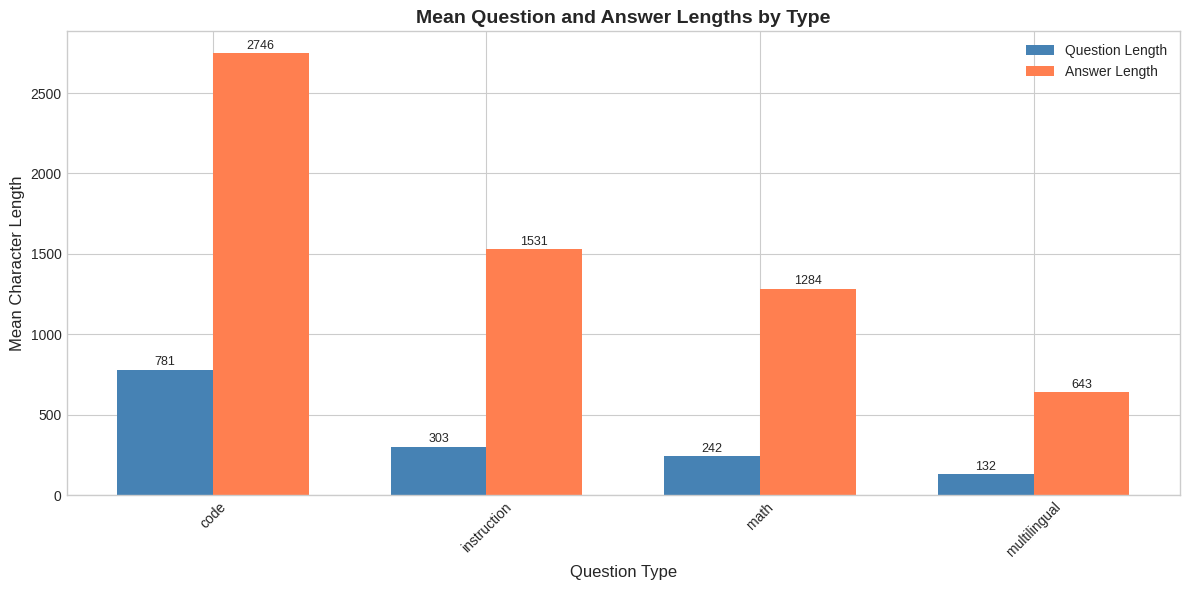

\nStatistics by Question Type:


question_length                answer_length                   \
                        mean median     std          mean  median      std   
Type                                                                         
code                  780.92  567.5  607.73       2746.31  2506.5  1425.64   
instruction           302.82  280.0  139.70       1530.66  1268.5  1229.12   
math                  241.80  207.0  186.36       1284.36  1236.0   888.33   
multilingual          131.50   58.0  273.69        643.11   473.0   577.24   

             question_word_count        answer_word_count         
                            mean median              mean median  
Type                                                              
code                      120.80   91.0            377.93  373.0  
instruction                46.89   44.0            214.15  183.0  
math                       41.07   36.0            242.54  231.0  
multilingual               17.78    8.0             84.02   61.0

In [20]:
# Grouped bar chart - Mean lengths by type
mean_stats = df.groupby('Type')[['question_length', 'answer_length']].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(mean_stats.index))
width = 0.35

bars1 = ax.bar(x - width/2, mean_stats['question_length'], width, label='Question Length', color='steelblue')
bars2 = ax.bar(x + width/2, mean_stats['answer_length'], width, label='Answer Length', color='coral')

ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Mean Character Length', fontsize=12)
ax.set_title('Mean Question and Answer Lengths by Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(mean_stats.index, rotation=45)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Statistics summary
stats_by_type = df.groupby('Type').agg({
    'question_length': ['mean', 'median', 'std'],
    'answer_length': ['mean', 'median', 'std'],
    'question_word_count': ['mean', 'median'],
    'answer_word_count': ['mean', 'median']
}).round(2)
print("\\nStatistics by Question Type:")
stats_by_type

---
## Fine-tuning the Model
<a name="Train"></a>
Now let's fine-tune our model on this dataset. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run.

In [21]:
# Format dataset for training
def formatting_prompts_func(examples):
    texts = []
    for question, answer in zip(examples["Question"], examples["Answer"]):
        messages = [
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer}
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return {"text": texts}

# Format the dataset
formatted_dataset = dataset.map(formatting_prompts_func, batched=True)
print(f"Formatted dataset with {len(formatted_dataset)} samples")

Map:   0%|          | 0/31870 [00:00<?, ? examples/s]

Formatted dataset with 31870 samples


In [22]:
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback
import math

# Custom callback to track training metrics for visualization
class TrainingMetricsCallback(TrainerCallback):
    def __init__(self):
        self.training_loss = []
        self.learning_rates = []
        self.steps = []
        self.grad_norms = []
        self.perplexities = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            step = state.global_step
            self.steps.append(step)

            # Training loss
            if "loss" in logs:
                loss = logs["loss"]
                self.training_loss.append(loss)
                # Calculate perplexity from loss
                perplexity = math.exp(loss) if loss < 100 else float('inf')
                self.perplexities.append(perplexity)

            # Learning rate
            if "learning_rate" in logs:
                self.learning_rates.append(logs["learning_rate"])

            # Gradient norm (if available)
            if "grad_norm" in logs:
                self.grad_norms.append(logs["grad_norm"])

# Initialize callback
metrics_callback = TrainingMetricsCallback()

FastLanguageModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = formatted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        max_steps = 240,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 8,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        dataset_text_field = "text",
        max_seq_length = 2048,
        # Enable gradient norm logging
        include_num_input_tokens_seen = True,
    ),
    callbacks = [metrics_callback],
)
print("Trainer configured with metrics callback for monitoring")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/31870 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer configured with metrics callback for monitoring


In [23]:
# Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
7.803 GB of memory reserved.


In [24]:
# Train the model
trainer_stats = trainer.train()

In [25]:
# Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

# Extract training history from trainer
training_history = trainer.state.log_history
print(f"\nTotal logged steps: {len(training_history)}")

9697.2613 seconds used for training.
161.62 minutes used for training.
Peak reserved memory = 14.139 GB.
Peak reserved memory for training = 6.336 GB.
Peak reserved memory % of max memory = 97.089 %.
Peak reserved memory for training % of max memory = 43.508 %.

Total logged steps: 31


##  Training Metrics Visualization

Comprehensive visualization of training dynamics including:
- **Loss Curves**: Training loss progression over steps
- **Learning Rate Schedule**: LR changes during training
- **Perplexity**: Model confidence/uncertainty metric (perplexity = exp(loss))
- **Gradient Norms**: Training stability indicator
- **Interactive Dashboards**: Combined metric views

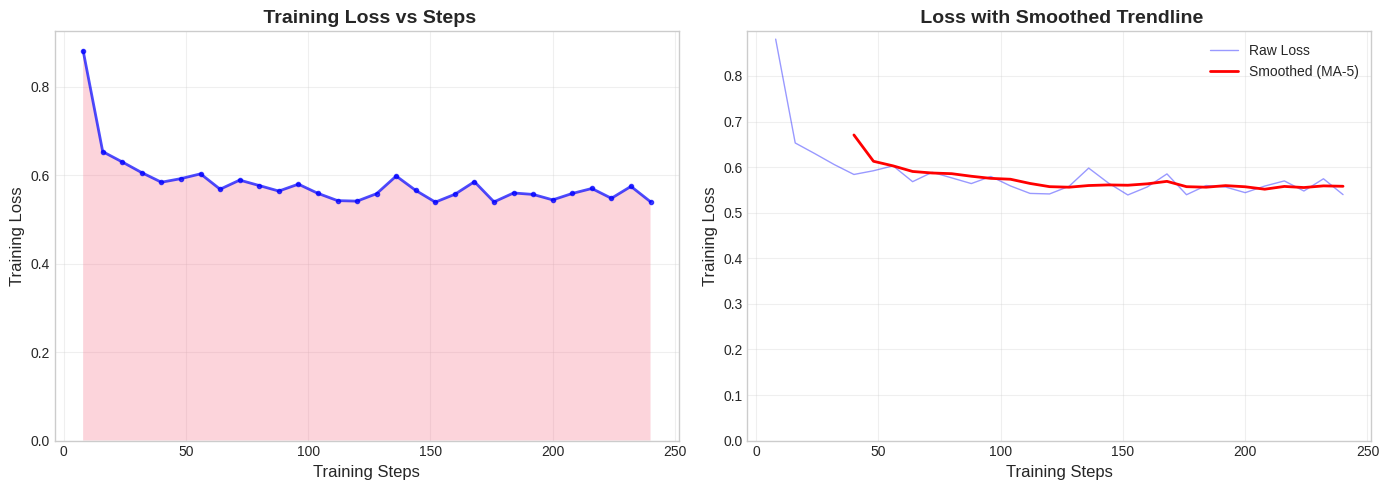

Initial Loss: 0.8808
Final Loss: 0.5397
Loss Reduction: 38.73%


In [26]:
# ============================================
# 1. Training Loss Curve
# ============================================
import matplotlib.pyplot as plt
import numpy as np

# Extract loss from training history
steps = []
losses = []
for entry in training_history:
    if 'loss' in entry and 'step' in entry:
        steps.append(entry['step'])
        losses.append(entry['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss vs Steps
axes[0].plot(steps, losses, 'b-', linewidth=2, marker='o', markersize=3, alpha=0.7)
axes[0].fill_between(steps, losses, alpha=0.3)
axes[0].set_xlabel('Training Steps', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title(' Training Loss vs Steps', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Loss with smoothed trendline (moving average)
if len(losses) > 3:
    window_size = min(5, len(losses)//2)
    if window_size > 1:
        smoothed = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
        smoothed_steps = steps[window_size-1:]
        axes[1].plot(steps, losses, 'b-', alpha=0.4, linewidth=1, label='Raw Loss')
        axes[1].plot(smoothed_steps, smoothed, 'r-', linewidth=2, label=f'Smoothed (MA-{window_size})')
        axes[1].legend(fontsize=10)
    else:
        axes[1].plot(steps, losses, 'b-', linewidth=2, marker='o', markersize=3)
else:
    axes[1].plot(steps, losses, 'b-', linewidth=2, marker='o', markersize=3)
axes[1].set_xlabel('Training Steps', fontsize=12)
axes[1].set_ylabel('Training Loss', fontsize=12)
axes[1].set_title(' Loss with Smoothed Trendline', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial Loss: {losses[0]:.4f}")
print(f"Final Loss: {losses[-1]:.4f}")
print(f"Loss Reduction: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

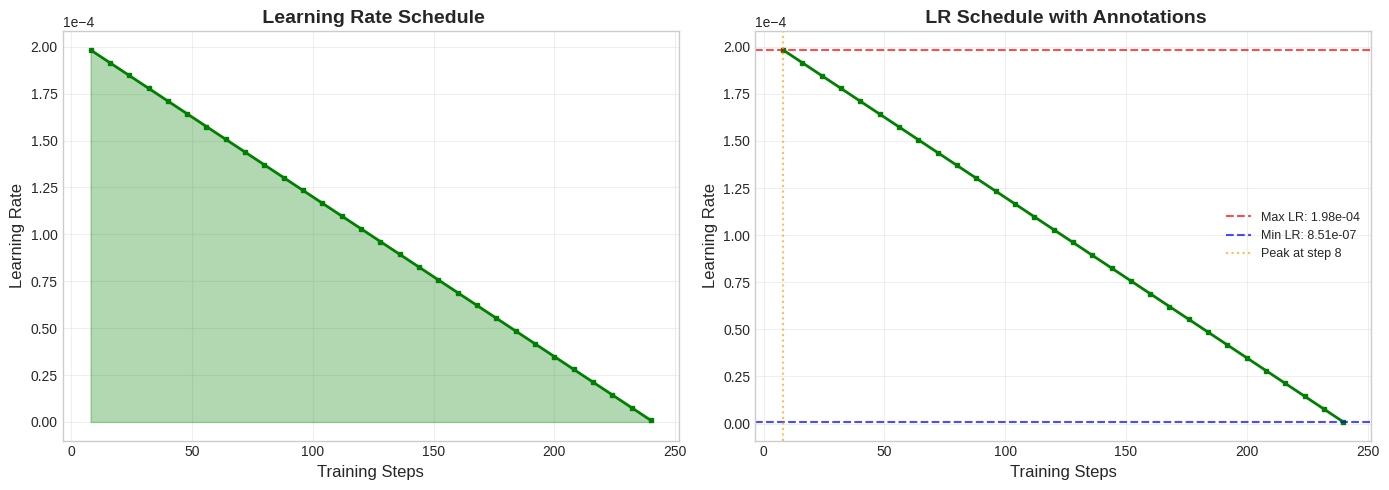

Initial LR: 1.98e-04
Peak LR: 1.98e-04
Final LR: 8.51e-07


In [27]:
# ============================================
# 2. Learning Rate Schedule
# ============================================
lr_steps = []
learning_rates = []
for entry in training_history:
    if 'learning_rate' in entry and 'step' in entry:
        lr_steps.append(entry['step'])
        learning_rates.append(entry['learning_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning Rate vs Steps
if learning_rates:
    axes[0].plot(lr_steps, learning_rates, 'g-', linewidth=2, marker='s', markersize=3)
    axes[0].fill_between(lr_steps, learning_rates, alpha=0.3, color='green')
    axes[0].set_xlabel('Training Steps', fontsize=12)
    axes[0].set_ylabel('Learning Rate', fontsize=12)
    axes[0].set_title(' Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

    # Learning Rate with annotations
    axes[1].plot(lr_steps, learning_rates, 'g-', linewidth=2, marker='s', markersize=3)
    axes[1].axhline(y=max(learning_rates), color='r', linestyle='--', alpha=0.7, label=f'Max LR: {max(learning_rates):.2e}')
    axes[1].axhline(y=min(learning_rates), color='b', linestyle='--', alpha=0.7, label=f'Min LR: {min(learning_rates):.2e}')
    if len(learning_rates) > 1:
        # Mark warmup end (where LR peaks)
        peak_idx = np.argmax(learning_rates)
        axes[1].axvline(x=lr_steps[peak_idx], color='orange', linestyle=':', alpha=0.7, label=f'Peak at step {lr_steps[peak_idx]}')
    axes[1].set_xlabel('Training Steps', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title(' LR Schedule with Annotations', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=9)
    axes[1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
else:
    axes[0].text(0.5, 0.5, 'No learning rate data available', ha='center', va='center', fontsize=14)
    axes[1].text(0.5, 0.5, 'No learning rate data available', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('learning_rate_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

if learning_rates:
    print(f"Initial LR: {learning_rates[0]:.2e}")
    print(f"Peak LR: {max(learning_rates):.2e}")
    print(f"Final LR: {learning_rates[-1]:.2e}")

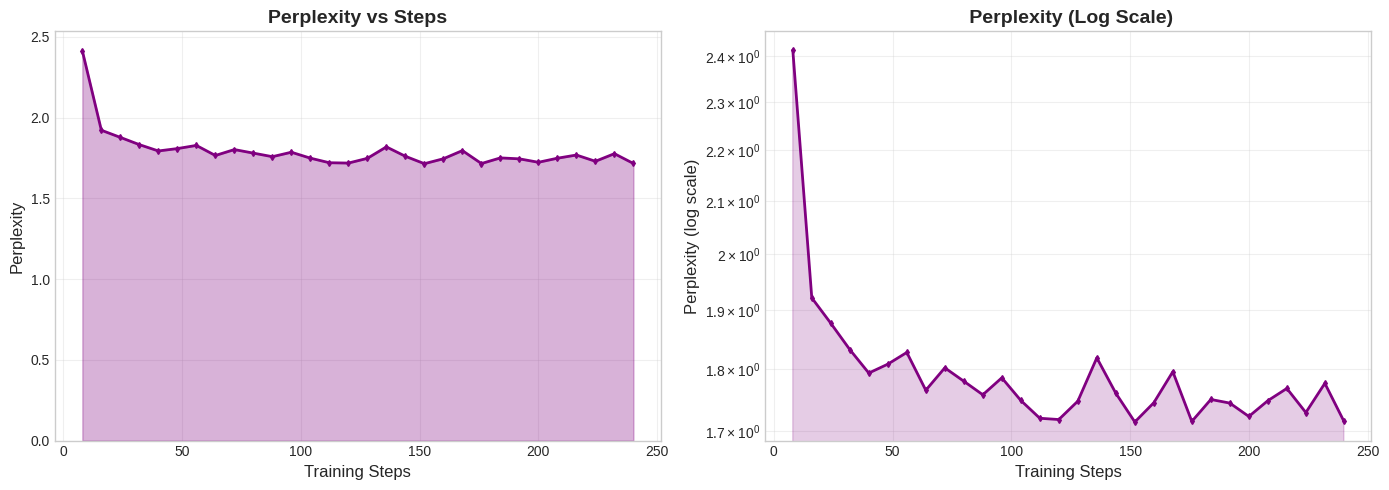

Initial Perplexity: 2.41
Final Perplexity: 1.72
Perplexity Reduction: 28.90%


In [28]:
# ============================================
# 3. Perplexity Curve (perplexity = exp(loss))
# ============================================
# Perplexity is a measure of model uncertainty - lower is better
perplexities = [np.exp(l) for l in losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perplexity vs Steps
axes[0].plot(steps, perplexities, 'purple', linewidth=2, marker='d', markersize=3)
axes[0].fill_between(steps, perplexities, alpha=0.3, color='purple')
axes[0].set_xlabel('Training Steps', fontsize=12)
axes[0].set_ylabel('Perplexity', fontsize=12)
axes[0].set_title('Perplexity vs Steps', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Log-scale perplexity for better visualization of large changes
axes[1].semilogy(steps, perplexities, 'purple', linewidth=2, marker='d', markersize=3)
axes[1].fill_between(steps, perplexities, alpha=0.2, color='purple')
axes[1].set_xlabel('Training Steps', fontsize=12)
axes[1].set_ylabel('Perplexity (log scale)', fontsize=12)
axes[1].set_title(' Perplexity (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('perplexity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial Perplexity: {perplexities[0]:.2f}")
print(f"Final Perplexity: {perplexities[-1]:.2f}")
print(f"Perplexity Reduction: {((perplexities[0] - perplexities[-1]) / perplexities[0] * 100):.2f}%")

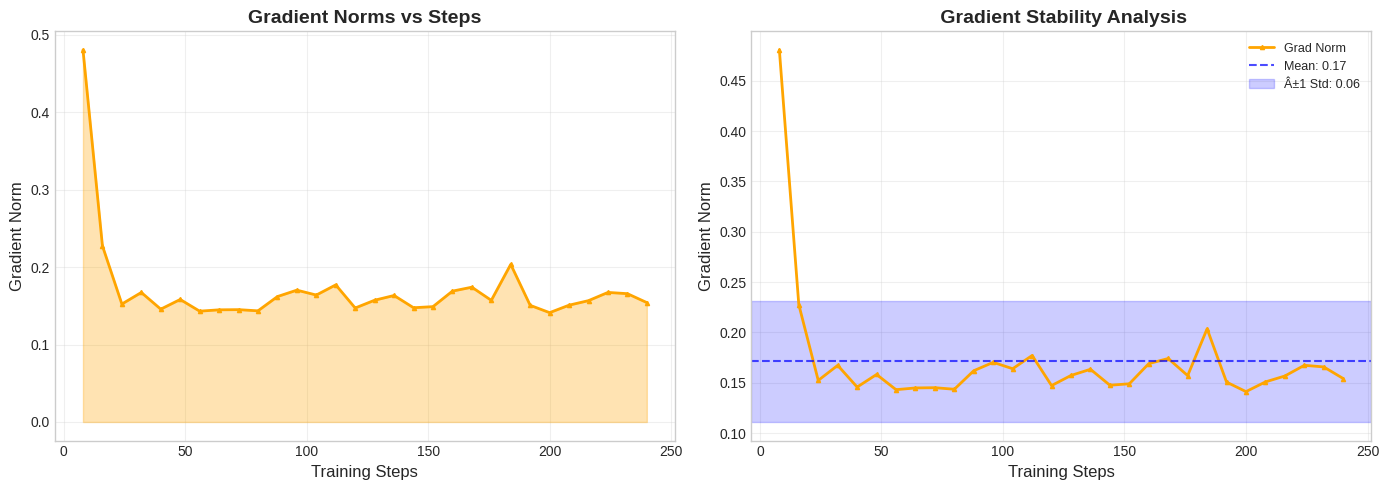

Mean Gradient Norm: 0.1713
Std Gradient Norm: 0.0602
Max Gradient Norm: 0.4806
Min Gradient Norm: 0.1412
 Gradient norms are stable throughout training


In [29]:
# ============================================
# 4. Gradient Norm Monitoring
# ============================================
# Gradient norms indicate training stability
# Large spikes may indicate instability

grad_steps = []
grad_norms = []
for entry in training_history:
    if 'grad_norm' in entry and 'step' in entry:
        grad_steps.append(entry['step'])
        grad_norms.append(entry['grad_norm'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if grad_norms:
    # Gradient Norms vs Steps
    axes[0].plot(grad_steps, grad_norms, 'orange', linewidth=2, marker='^', markersize=3)
    axes[0].fill_between(grad_steps, grad_norms, alpha=0.3, color='orange')
    axes[0].set_xlabel('Training Steps', fontsize=12)
    axes[0].set_ylabel('Gradient Norm', fontsize=12)
    axes[0].set_title('Gradient Norms vs Steps', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Gradient norm with stability zones
    mean_grad = np.mean(grad_norms)
    std_grad = np.std(grad_norms)
    axes[1].plot(grad_steps, grad_norms, 'orange', linewidth=2, marker='^', markersize=3, label='Grad Norm')
    axes[1].axhline(y=mean_grad, color='blue', linestyle='--', alpha=0.7, label=f'Mean: {mean_grad:.2f}')
    axes[1].axhspan(mean_grad - std_grad, mean_grad + std_grad, alpha=0.2, color='blue', label=f'Â±1 Std: {std_grad:.2f}')
    axes[1].set_xlabel('Training Steps', fontsize=12)
    axes[1].set_ylabel('Gradient Norm', fontsize=12)
    axes[1].set_title(' Gradient Stability Analysis', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('gradient_norms.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Mean Gradient Norm: {mean_grad:.4f}")
    print(f"Std Gradient Norm: {std_grad:.4f}")
    print(f"Max Gradient Norm: {max(grad_norms):.4f}")
    print(f"Min Gradient Norm: {min(grad_norms):.4f}")

    # Check for gradient explosion/vanishing
    if max(grad_norms) > 10 * mean_grad:
        print(" Warning: Large gradient spikes detected - potential instability")
    else:
        print(" Gradient norms are stable throughout training")
else:
    axes[0].text(0.5, 0.5, 'No gradient norm data available\n(Enable gradient logging in trainer)',
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[1].text(0.5, 0.5, 'No gradient norm data available',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    plt.tight_layout()
    plt.show()
    print("Note: Gradient norms were not logged during training")

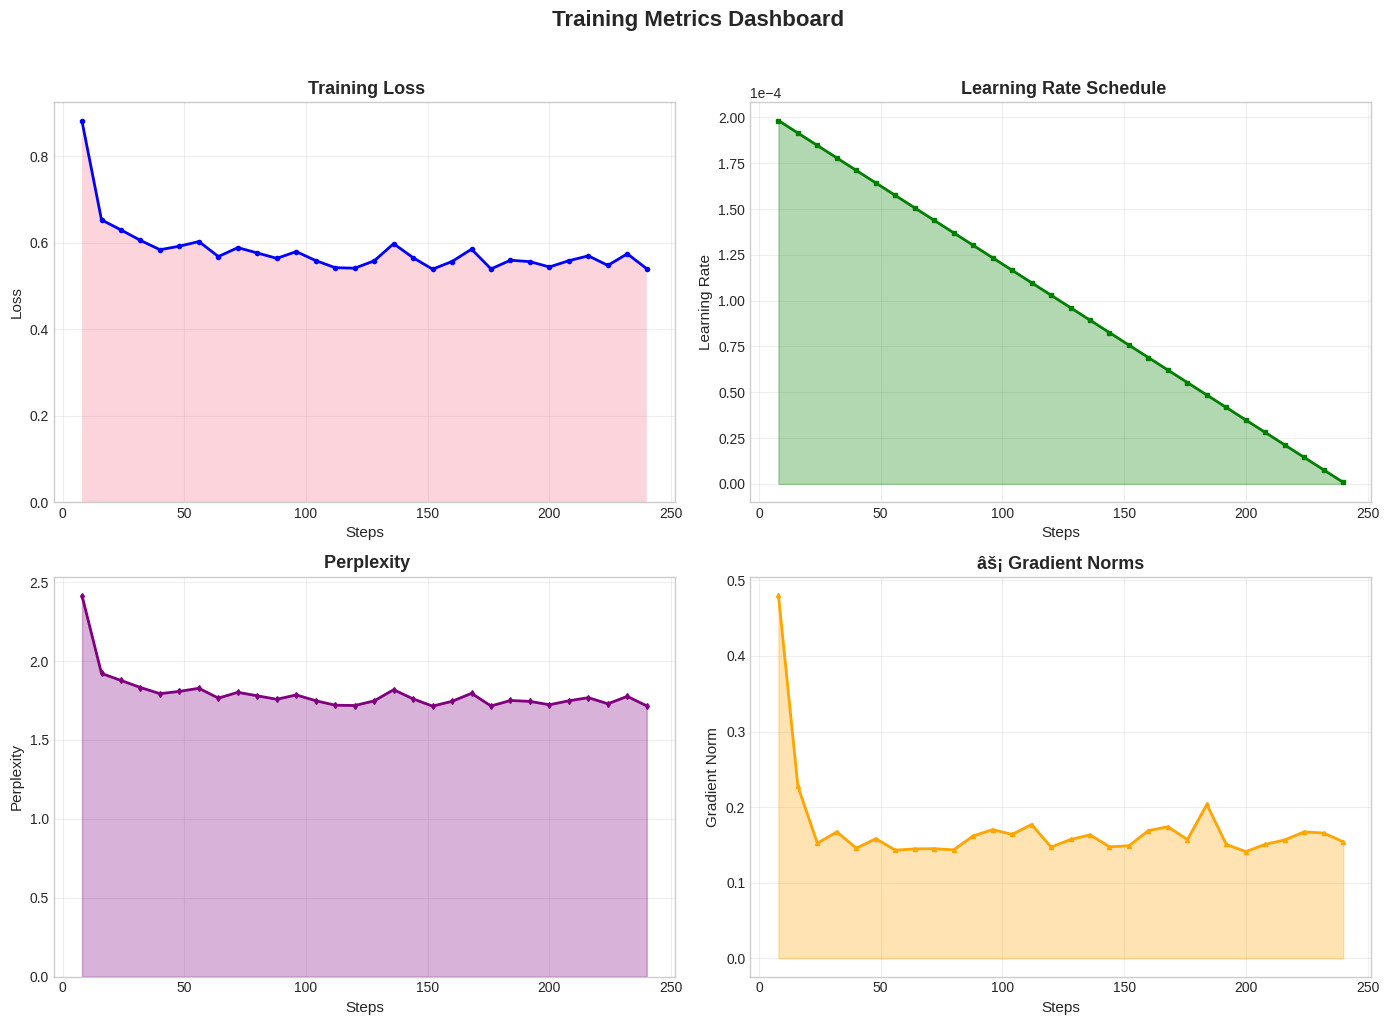


 TRAINING SUMMARY
Total Steps: 30
Loss: 0.8808 â†’ 0.5397 (â†“38.7%)
Perplexity: 2.41 â†’ 1.72 (â†“28.9%)
Learning Rate: 1.98e-04 â†’ 8.51e-07
Gradient Norm: mean=0.17, std=0.06


In [30]:
# ============================================
# 5. Combined Training Dashboard (Matplotlib)
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
axes[0, 0].plot(steps, losses, 'b-', linewidth=2, marker='o', markersize=3)
axes[0, 0].fill_between(steps, losses, alpha=0.3)
axes[0, 0].set_xlabel('Steps', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title(' Training Loss', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(bottom=0)

# Plot 2: Learning Rate
if learning_rates:
    axes[0, 1].plot(lr_steps, learning_rates, 'g-', linewidth=2, marker='s', markersize=3)
    axes[0, 1].fill_between(lr_steps, learning_rates, alpha=0.3, color='green')
    axes[0, 1].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
else:
    axes[0, 1].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, transform=axes[0, 1].transAxes)
axes[0, 1].set_xlabel('Steps', fontsize=11)
axes[0, 1].set_ylabel('Learning Rate', fontsize=11)
axes[0, 1].set_title(' Learning Rate Schedule', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Perplexity
axes[1, 0].plot(steps, perplexities, 'purple', linewidth=2, marker='d', markersize=3)
axes[1, 0].fill_between(steps, perplexities, alpha=0.3, color='purple')
axes[1, 0].set_xlabel('Steps', fontsize=11)
axes[1, 0].set_ylabel('Perplexity', fontsize=11)
axes[1, 0].set_title(' Perplexity', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(bottom=0)

# Plot 4: Gradient Norms
if grad_norms:
    axes[1, 1].plot(grad_steps, grad_norms, 'orange', linewidth=2, marker='^', markersize=3)
    axes[1, 1].fill_between(grad_steps, grad_norms, alpha=0.3, color='orange')
else:
    axes[1, 1].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=14, transform=axes[1, 1].transAxes)
axes[1, 1].set_xlabel('Steps', fontsize=11)
axes[1, 1].set_ylabel('Gradient Norm', fontsize=11)
axes[1, 1].set_title('âš¡ Gradient Norms', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(' Training Metrics Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*60)
print(" TRAINING SUMMARY")
print("="*60)
print(f"Total Steps: {len(steps)}")
print(f"Loss: {losses[0]:.4f} â†’ {losses[-1]:.4f} (â†“{((losses[0]-losses[-1])/losses[0]*100):.1f}%)")
print(f"Perplexity: {perplexities[0]:.2f} â†’ {perplexities[-1]:.2f} (â†“{((perplexities[0]-perplexities[-1])/perplexities[0]*100):.1f}%)")
if learning_rates:
    print(f"Learning Rate: {learning_rates[0]:.2e} â†’ {learning_rates[-1]:.2e}")
if grad_norms:
    print(f"Gradient Norm: mean={np.mean(grad_norms):.2f}, std={np.std(grad_norms):.2f}")
print("="*60)

In [31]:
# ============================================
# 6. Interactive Training Dashboard (Plotly)
# ============================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Training Loss', ' Learning Rate', ' Perplexity', ' Gradient Norms'),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# Training Loss
fig.add_trace(
    go.Scatter(x=steps, y=losses, mode='lines+markers', name='Loss',
               line=dict(color='#3498db', width=2),
               marker=dict(size=4),
               fill='tozeroy', fillcolor='rgba(52, 152, 219, 0.2)'),
    row=1, col=1
)

# Learning Rate
if learning_rates:
    fig.add_trace(
        go.Scatter(x=lr_steps, y=learning_rates, mode='lines+markers', name='Learning Rate',
                   line=dict(color='#27ae60', width=2),
                   marker=dict(size=4),
                   fill='tozeroy', fillcolor='rgba(39, 174, 96, 0.2)'),
        row=1, col=2
    )

# Perplexity
fig.add_trace(
    go.Scatter(x=steps, y=perplexities, mode='lines+markers', name='Perplexity',
               line=dict(color='#9b59b6', width=2),
               marker=dict(size=4),
               fill='tozeroy', fillcolor='rgba(155, 89, 182, 0.2)'),
    row=2, col=1
)

# Gradient Norms
if grad_norms:
    fig.add_trace(
        go.Scatter(x=grad_steps, y=grad_norms, mode='lines+markers', name='Grad Norm',
                   line=dict(color='#e67e22', width=2),
                   marker=dict(size=4),
                   fill='tozeroy', fillcolor='rgba(230, 126, 34, 0.2)'),
        row=2, col=2
    )

fig.update_layout(
    title=dict(text=' Interactive Training Metrics Dashboard', font=dict(size=20)),
    height=700,
    showlegend=False,
    template='plotly_white'
)

# Update axes labels
fig.update_xaxes(title_text='Steps', row=1, col=1)
fig.update_xaxes(title_text='Steps', row=1, col=2)
fig.update_xaxes(title_text='Steps', row=2, col=1)
fig.update_xaxes(title_text='Steps', row=2, col=2)
fig.update_yaxes(title_text='Loss', row=1, col=1)
fig.update_yaxes(title_text='LR', row=1, col=2)
fig.update_yaxes(title_text='Perplexity', row=2, col=1)
fig.update_yaxes(title_text='Grad Norm', row=2, col=2)

fig.show()

/tmp/ipykernel_947/2550092226.py:41: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



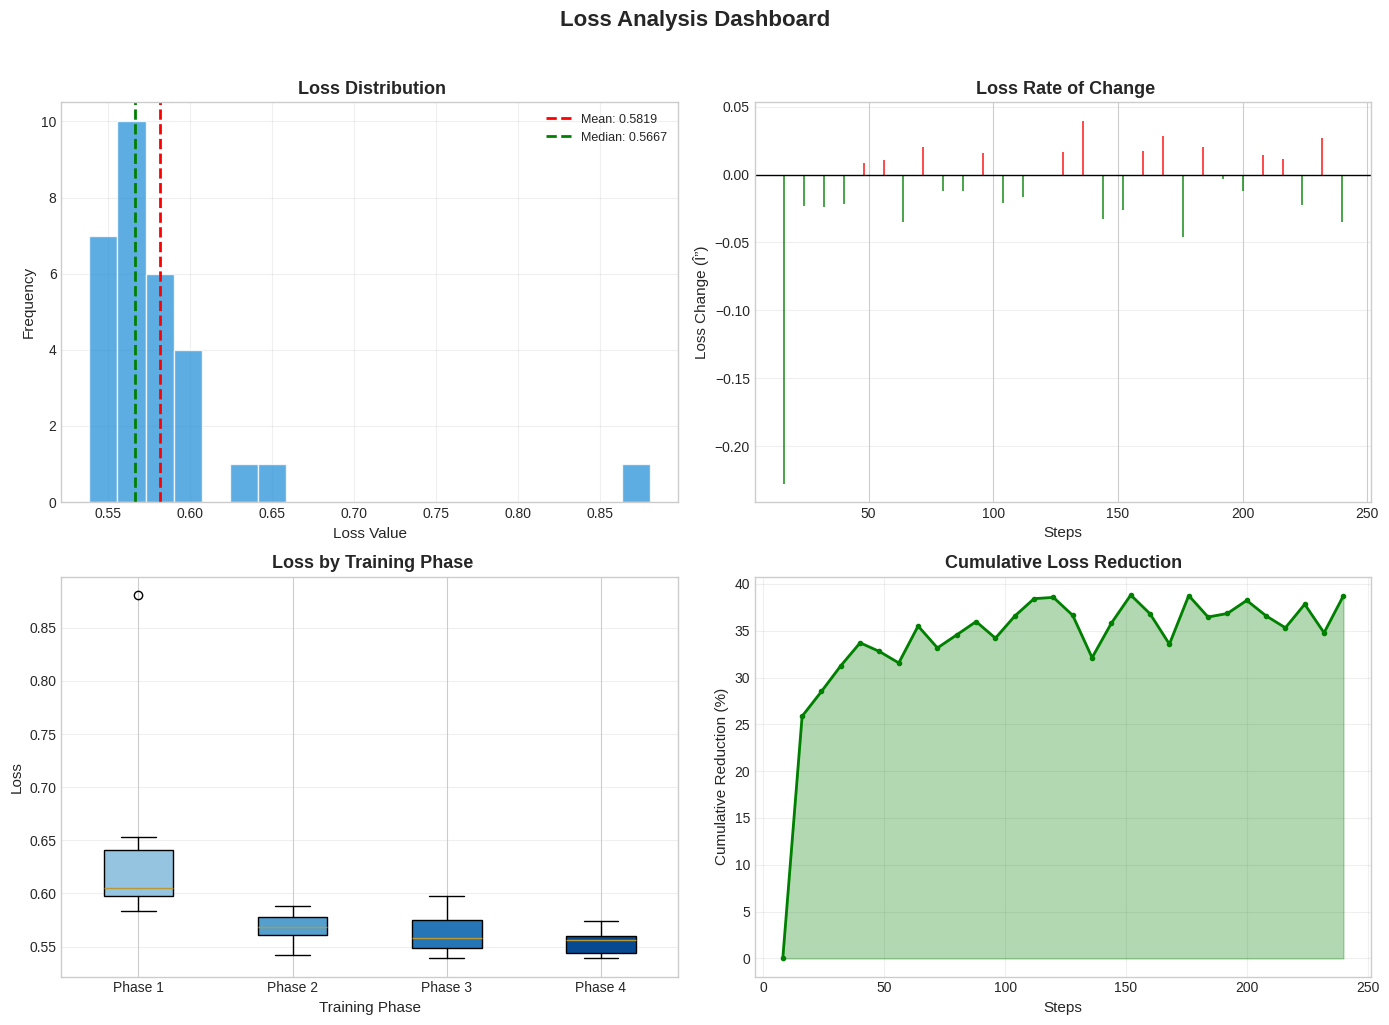


Loss Statistics:
  Mean: 0.5819
  Median: 0.5667
  Std Dev: 0.0616
  Min: 0.5389
  Max: 0.8808


In [32]:
# ============================================
# 7. Loss Distribution & Rate of Change Analysis
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss Distribution (Histogram)
axes[0, 0].hist(losses, bins=min(20, len(losses)), color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(x=np.mean(losses), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(losses):.4f}')
axes[0, 0].axvline(x=np.median(losses), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(losses):.4f}')
axes[0, 0].set_xlabel('Loss Value', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title(' Loss Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Loss Rate of Change (First Derivative)
if len(losses) > 1:
    loss_diff = np.diff(losses)
    diff_steps = steps[1:]
    colors = ['green' if d < 0 else 'red' for d in loss_diff]
    axes[0, 1].bar(diff_steps, loss_diff, color=colors, alpha=0.7, width=0.8)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].set_xlabel('Steps', fontsize=11)
    axes[0, 1].set_ylabel('Loss Change (Î”)', fontsize=11)
    axes[0, 1].set_title(' Loss Rate of Change', fontsize=13, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[0, 1].text(0.5, 0.5, 'Need more steps', ha='center', va='center', fontsize=12, transform=axes[0, 1].transAxes)

# Box Plot of Loss by Training Phase
n_phases = min(4, len(losses))
phase_size = len(losses) // n_phases
phases_data = []
phase_labels = []
for i in range(n_phases):
    start_idx = i * phase_size
    end_idx = start_idx + phase_size if i < n_phases - 1 else len(losses)
    phases_data.append(losses[start_idx:end_idx])
    phase_labels.append(f'Phase {i+1}')

bp = axes[1, 0].boxplot(phases_data, labels=phase_labels, patch_artist=True)
colors_bp = plt.cm.Blues(np.linspace(0.4, 0.9, n_phases))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1, 0].set_xlabel('Training Phase', fontsize=11)
axes[1, 0].set_ylabel('Loss', fontsize=11)
axes[1, 0].set_title(' Loss by Training Phase', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Cumulative Loss Reduction
cumulative_reduction = [(losses[0] - losses[i]) / losses[0] * 100 for i in range(len(losses))]
axes[1, 1].plot(steps, cumulative_reduction, 'g-', linewidth=2, marker='o', markersize=3)
axes[1, 1].fill_between(steps, cumulative_reduction, alpha=0.3, color='green')
axes[1, 1].set_xlabel('Steps', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Reduction (%)', fontsize=11)
axes[1, 1].set_title('Cumulative Loss Reduction', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Loss Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print(f"\nLoss Statistics:")
print(f"  Mean: {np.mean(losses):.4f}")
print(f"  Median: {np.median(losses):.4f}")
print(f"  Std Dev: {np.std(losses):.4f}")
print(f"  Min: {np.min(losses):.4f}")
print(f"  Max: {np.max(losses):.4f}")

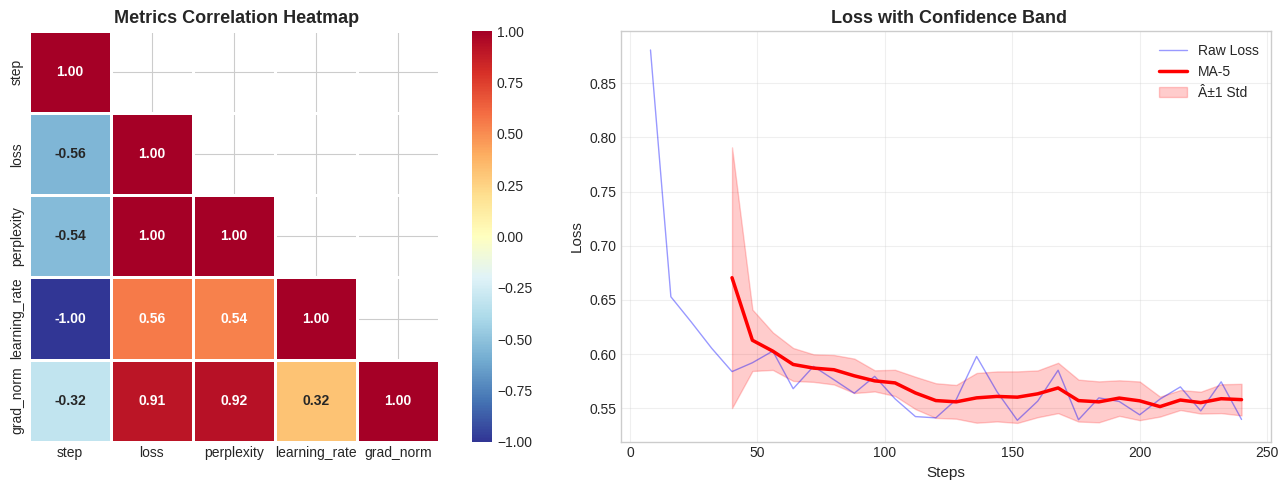

 Correlation Insights:
  Loss vs perplexity: 0.999
  Loss vs learning_rate: 0.560
  Loss vs grad_norm: 0.907


In [33]:
# ============================================
# 8. Correlation Heatmap & Training Efficiency
# ============================================
import seaborn as sns
import pandas as pd

# Build metrics dataframe for correlation analysis
metrics_dict = {'step': steps, 'loss': losses, 'perplexity': perplexities}
if learning_rates and len(learning_rates) == len(steps):
    metrics_dict['learning_rate'] = learning_rates
if grad_norms and len(grad_norms) == len(steps):
    metrics_dict['grad_norm'] = grad_norms

metrics_df = pd.DataFrame(metrics_dict)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Heatmap
if len(metrics_df.columns) > 2:
    corr_matrix = metrics_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
                ax=axes[0], mask=mask, square=True, linewidths=1,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    axes[0].set_title(' Metrics Correlation Heatmap', fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'Need more metrics for correlation',
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title(' Metrics Correlation', fontsize=13, fontweight='bold')

# Training Efficiency: Loss per Step vs Running Average
if len(losses) > 2:
    window = min(5, len(losses)//2)
    if window > 1:
        efficiency = pd.Series(losses).rolling(window=window).mean()
        axes[1].plot(steps, losses, 'b-', alpha=0.4, linewidth=1, label='Raw Loss')
        axes[1].plot(steps, efficiency, 'r-', linewidth=2.5, label=f'MA-{window}')

        # Add confidence interval
        rolling_std = pd.Series(losses).rolling(window=window).std()
        upper = efficiency + rolling_std
        lower = efficiency - rolling_std
        axes[1].fill_between(steps, lower, upper, alpha=0.2, color='red', label='Â±1 Std')

        axes[1].legend(fontsize=10)
        axes[1].set_xlabel('Steps', fontsize=11)
        axes[1].set_ylabel('Loss', fontsize=11)
        axes[1].set_title(' Loss with Confidence Band', fontsize=13, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].plot(steps, losses, 'b-', linewidth=2)
        axes[1].set_xlabel('Steps', fontsize=11)
        axes[1].set_ylabel('Loss', fontsize=11)
        axes[1].set_title('Training Loss', fontsize=13, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
else:
    axes[1].plot(steps, losses, 'b-', linewidth=2)
    axes[1].set_xlabel('Steps', fontsize=11)
    axes[1].set_ylabel('Loss', fontsize=11)
    axes[1].set_title(' Training Loss', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_and_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlation insights
if len(metrics_df.columns) > 2:
    print(" Correlation Insights:")
    corr = metrics_df.corr()
    for col in corr.columns:
        if col != 'step' and col != 'loss':
            print(f"  Loss vs {col}: {corr.loc['loss', col]:.3f}")

In [34]:
# ============================================
# 9. Interactive Training Progress & Summary Gauges
# ============================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create summary dashboard with gauges
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "indicator"}, {"type": "indicator"}],
           [{"type": "scatter"}, {"type": "scatter"}]],
    subplot_titles=('', '', 'Loss Progression', 'Perplexity Progression'),
    vertical_spacing=0.2
)

# Calculate metrics
loss_reduction_pct = ((losses[0] - losses[-1]) / losses[0]) * 100
perplexity_reduction_pct = ((perplexities[0] - perplexities[-1]) / perplexities[0]) * 100

# Gauge 1: Loss Reduction
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=loss_reduction_pct,
        title={'text': "Loss Reduction %", 'font': {'size': 14}},
        delta={'reference': 0, 'increasing': {'color': "green"}},
        gauge={
            'axis': {'range': [0, 100], 'tickwidth': 1},
            'bar': {'color': "#27ae60"},
            'steps': [
                {'range': [0, 25], 'color': "#e74c3c"},
                {'range': [25, 50], 'color': "#f39c12"},
                {'range': [50, 75], 'color': "#f1c40f"},
                {'range': [75, 100], 'color': "#2ecc71"}
            ],
            'threshold': {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 50}
        }
    ),
    row=1, col=1
)

# Gauge 2: Perplexity Reduction
fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=perplexity_reduction_pct,
        title={'text': "Perplexity Reduction %", 'font': {'size': 14}},
        delta={'reference': 0, 'increasing': {'color': "green"}},
        gauge={
            'axis': {'range': [0, 100], 'tickwidth': 1},
            'bar': {'color': "#9b59b6"},
            'steps': [
                {'range': [0, 25], 'color': "#e74c3c"},
                {'range': [25, 50], 'color': "#f39c12"},
                {'range': [50, 75], 'color': "#f1c40f"},
                {'range': [75, 100], 'color': "#2ecc71"}
            ],
            'threshold': {'line': {'color': "red", 'width': 4}, 'thickness': 0.75, 'value': 50}
        }
    ),
    row=1, col=2
)

# Loss progression with markers for start/end
fig.add_trace(
    go.Scatter(x=steps, y=losses, mode='lines+markers', name='Loss',
               line=dict(color='#3498db', width=2),
               marker=dict(size=6)),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=[steps[0]], y=[losses[0]], mode='markers', name='Start',
               marker=dict(size=15, color='red', symbol='star')),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=[steps[-1]], y=[losses[-1]], mode='markers', name='End',
               marker=dict(size=15, color='green', symbol='star')),
    row=2, col=1
)

# Perplexity progression
fig.add_trace(
    go.Scatter(x=steps, y=perplexities, mode='lines+markers', name='Perplexity',
               line=dict(color='#9b59b6', width=2),
               marker=dict(size=6)),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=[steps[0]], y=[perplexities[0]], mode='markers', name='Start',
               marker=dict(size=15, color='red', symbol='star'), showlegend=False),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=[steps[-1]], y=[perplexities[-1]], mode='markers', name='End',
               marker=dict(size=15, color='green', symbol='star'), showlegend=False),
    row=2, col=2
)

fig.update_layout(
    title=dict(text=' Training Progress Summary', font=dict(size=20), x=0.5),
    height=700,
    showlegend=True,
    template='plotly_white'
)

fig.update_xaxes(title_text='Steps', row=2, col=1)
fig.update_xaxes(title_text='Steps', row=2, col=2)
fig.update_yaxes(title_text='Loss', row=2, col=1)
fig.update_yaxes(title_text='Perplexity', row=2, col=2)

fig.show()

# Final Summary
print("\n" + "-"*20)
print("TRAINING COMPLETE!")
print("-"*20)
print(f"\nðŸ“Š Final Metrics:")
print(f"   Initial Loss: {losses[0]:.4f} and Final Loss: {losses[-1]:.4f}")
print(f"   Loss Reduction: {loss_reduction_pct:.1f}%")
print(f"   Initial Perplexity: {perplexities[0]:.2f} and Final Perplexity: {perplexities[-1]:.2f}")
print(f"   Perplexity Reduction: {perplexity_reduction_pct:.1f}%")
print(f"   Total Training Steps: {len(steps)}")

<a name="Inference"></a>
### Inference
Let's run the model after fine-tuning to see how it performs on the math questions!

In [35]:
FastLanguageModel.for_inference(model) # Enable for inference!

sample = dataset[0]
question = sample["Question"]
expected_answer = sample["Answer"]

messages = [
    {"role": "user", "content": question}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
print(f"Question: {question}\n")
print("Model Response (after fine-tuning):")
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=512,
                   use_cache=True, temperature=0.7, top_p=0.9)
print(f"\n\nExpected Answer Preview: {expected_answer[:]}...")

Question: Consider the terms of an arithmetic sequence: $-\frac{1}{3}, y+2, 4y, \ldots$. Solve for $y$.

Model Response (after fine-tuning):


--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, 

<think>

</think>

 To solve for \( y \) in the arithmetic sequence \(-\frac{1}{3}, y + 2, 4y, \ldots\), we use the property that the difference between consecutive terms is constant (common difference).

1. **Find the common difference between the first two terms:**
   \[
   (y + 2) - \left(-\frac{1}{3}\right) = y + 2 + \frac{1}{3} = y + \frac{7}{3}
   \]

2. **Find the common difference between the second and third terms:**
   \[
   4y - (y + 2) = 4y - y - 2 = 3y - 2
   \]

3. **Set the two differences equal to each other:**
   \[
   y + \frac{7}{3} = 3y - 2
   \]

4. **Solve for \( y \):**
   \[
   y + \frac{7}{3} = 3y - 2
   \]
   \[
   \frac{7}{3} + 2 = 3y - y
   \]
   \[
   \frac{7}{3} + \frac{6}{3} = 2y
   \]
   \[
   \frac{13}{3} = 2y
   \]
   \[
   y = \frac{13}{6}
   \]

**Final Answer:**
\[
\boxed{\dfrac{13}{6}}
\]<|im_end|>


Expected Answer Preview:  The value of \( y \) is \boxed{\dfrac{5}{3}}....


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [36]:
model.save_pretrained("sarvam_math_lora")  # Local saving
tokenizer.save_pretrained("sarvam_math_lora")
# model.push_to_hub("your_name/sarvam_math_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/sarvam_math_lora", token = "YOUR_HF_TOKEN") # Online saving

('sarvam_math_lora/tokenizer_config.json',
 'sarvam_math_lora/chat_template.jinja',
 'sarvam_math_lora/tokenizer.json')

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [37]:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "sarvam_math_lora", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 2048,
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastLanguageModel.for_inference(model) # Enable for inference!

sample = dataset[5]
question = sample["Question"]

messages = [
    {"role": "user", "content": question}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
print(f"Question: {question}\n")
print("Model Response:")
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=2096,
                   use_cache=True, temperature=0.7, top_p=0.9)

Question: Julian is writing a comic book. On average, his story has 280 frames per page. In his 25-page book, 10 pages have 305 frames, 7 pages have 250 frames, and the remaining pages have the average number of frames. How many frames will there be in total in his comic book?

Model Response:
<think>

</think>

 To find the total number of frames in Julian's comic book, we need to calculate the frames for each type of page and sum them up.

1. **Pages with 305 frames:**
   - Number of pages: 10
   - Frames per page: 305
   - Total frames: \(10 \times 305 = 3050\) frames

2. **Pages with 250 frames:**
   - Number of pages: 7
   - Frames per page: 250
   - Total frames: \(7 \times 250 = 1750\) frames

3. **Remaining pages with average frames:**
   - Total pages: 25
   - Pages already counted: \(10 + 7 = 17\)
   - Remaining pages: \(25 - 17 = 8\)
   - Average frames per page: 280
   - Total frames: \(8 \times 280 = 2240\) frames

4. **Total frames in the comic book:**
   - Sum of frames 